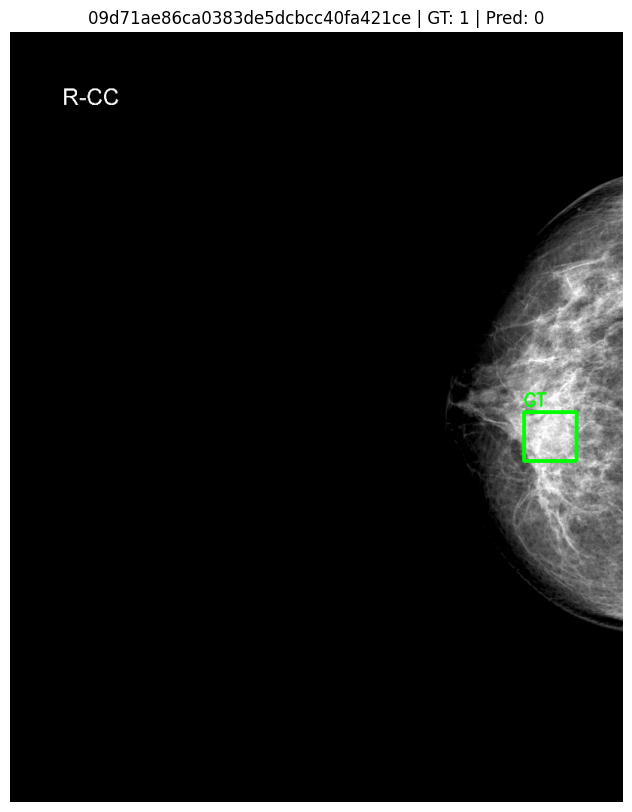

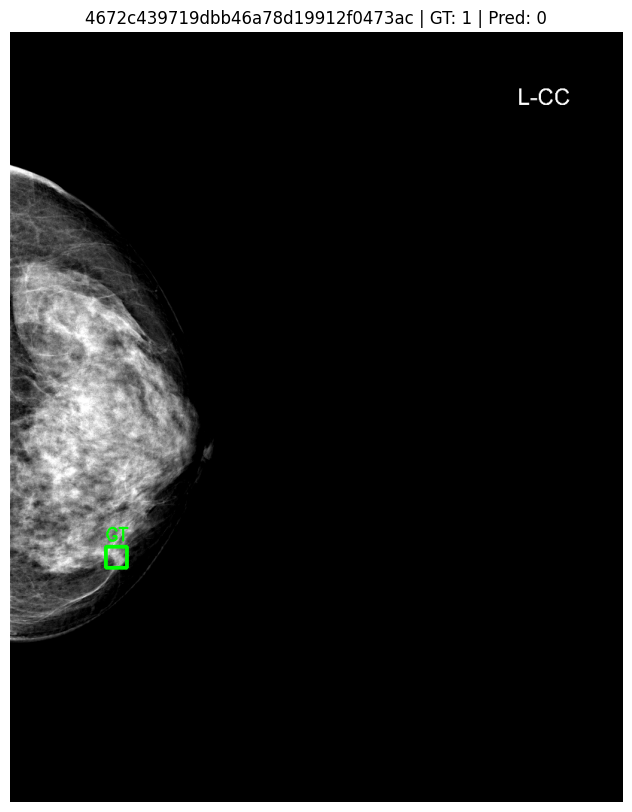

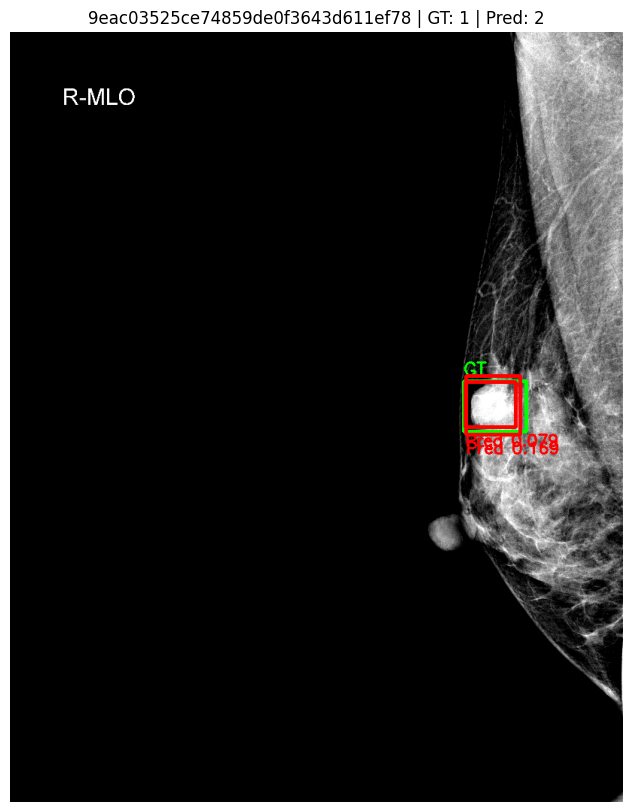

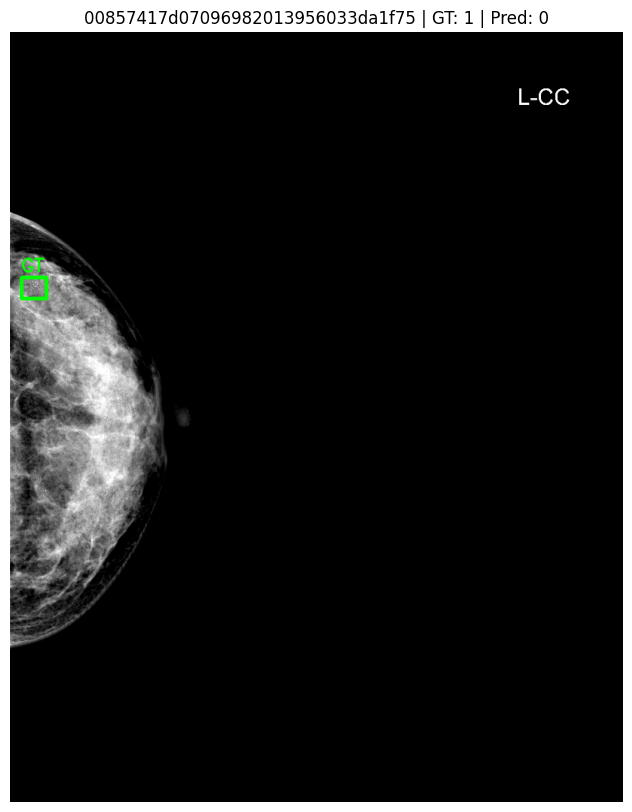

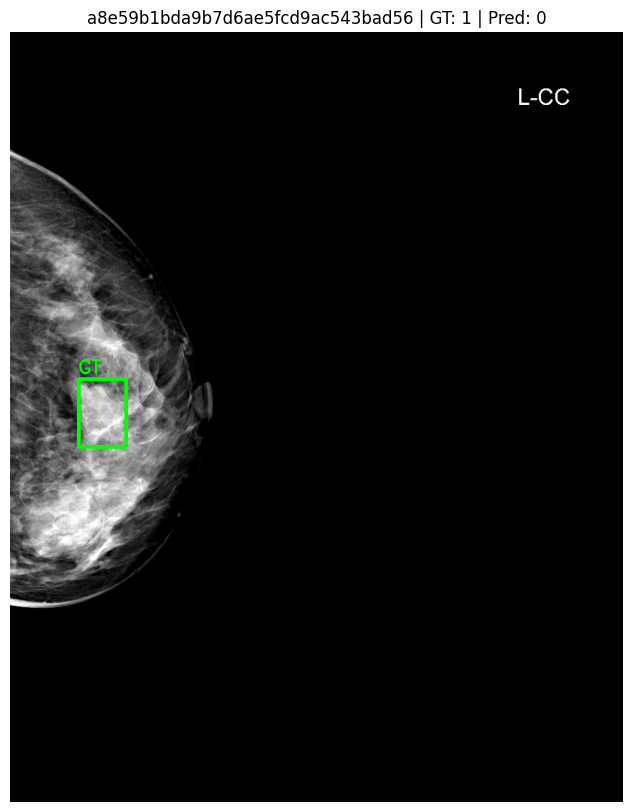

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from ultralytics import YOLO

from train_all_vindr_v2 import read_and_process_dicom

DATASET = Path("/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo")
MODEL_PATH = Path("/home/enric_sena/Desktop/Mammo/runs/detect/train-19/weights/best.pt")

IMG_SIZE = 1024
CONF = 0.1

images_dir = DATASET / "images" / "test"
labels_dir = DATASET / "labels" / "test"

label_files = [f for f in labels_dir.glob("*.txt") if f.read_text().strip()]

model = YOLO(str(MODEL_PATH))

for label_file in label_files[:5]:

    image_id = label_file.stem
    image_link = images_dir / f"{image_id}.jpg"
    dicom_path = image_link.resolve()

    image, _, _ = read_and_process_dicom(
        dicom_path,
        method="breast_tissue",
        calc_window=True,
        voi_func="LINEAR",
        imgsz=IMG_SIZE,
    )

    h, w = image.shape[:2]

    results = model.predict(
        source=image,
        imgsz=IMG_SIZE,
        conf=CONF,
        iou=0.7,
        device=0,
        verbose=False,
    )

    result = results[0]

    vis = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # GT
    for line in label_file.read_text().splitlines():
        parts = line.split()
        cls, xc, yc, bw, bh = map(float, parts[:5])

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)

        cv2.putText(
            vis,
            "GT",
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )

    # Predictions
    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()

        for box, conf in zip(boxes, confs):
            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 3)

            cv2.putText(
                vis,
                f"Pred {conf:.3f}",
                (x1, min(h - 10, y2 + 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 0, 0),
                2,
            )

    plt.figure(figsize=(12, 10))
    plt.imshow(vis)
    plt.title(
        f"{image_id} | GT: {len(label_file.read_text().splitlines())} | "
        f"Pred: {len(result.boxes) if result.boxes is not None else 0}"
    )
    plt.axis("off")
    plt.show()